#### 이메일 스팸 분류 모델 구현

#### 사용 데이터

- 데이터셋: `email_spam_logistic_tfidf_v3.pkl`
- 사용 채널: `이메일`
- 입력 특성: `text`
- 정답: `label`
- 모델: TF-IDF + LinearSVC
- 저장 파일: `email_spam_linearsvc_tfidf_v3.pkl`

#### 구현 흐름

1. 데이터 불러오기
2. 칼럼과 데이터 크기 확인
3. 이메일 행과 `label`, `text` 칼럼만 추출
4. 결측값·중복값·클래스 분포 확인
5. 문자열 길이 분포 확인
6. 결측값·빈 문자열·중복값 처리
7. 입력 데이터 `X`와 정답 `y` 분리
8. 학습용과 테스트용 데이터를 8:2로 분리
9. Pipeline 안에서 TF-IDF 숫자 벡터 변환
10. LinearSVC 모델 학습
11. Accuracy, Precision, Recall, F1-score, 혼동행렬 평가
12. 새로운 이메일의 예측값과 결정 점수 확인
13. 전체 이메일 데이터로 최종 모델 재학습
14. 최종 Pipeline을 `.pkl` 파일로 저장
15. 저장된 모델을 불러와 새로운 이메일 예측

> 지도학습은 정답이 있는 데이터를 학습하고, 비지도학습은 정답이 없는 데이터에서 구조를 찾는 방식이다.


In [23]:
# 주피터가 모델 객체를 화면에 표시하다가 생긴 인코딩 문제 방지
from sklearn import set_config
set_config(display='text')

In [24]:
# 0. 필요 도구 불러오기

import pickle
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [25]:
# 1. 데이터셋 불러오기

DATA_PATH = 'korean_spam_ham_binary_dataset_6272row.csv'

data = pd.read_csv(
    DATA_PATH,
    encoding='utf-8-sig'
)

data.head()


,id,label,label_name,category,subcategory,channel,text,reason,source_note
0,1,1,스팸_사기,광고성스팸,불법의약품광고,이메일,제목: 병원처방전 없이 구매 가능한 발기부전치료제 안내\r\n본문: 해외직구로 저...,"처방전 없는 전문의약품 판매, 출처불명 해외직구 사이트",나무위키 스팸메일 문서의 불법 의약품 사이트 광고 유형 참고
1,2,0,정상,정상,쇼핑주문확인,이메일,제목: [29CM] 주문이 정상적으로 완료되었습니다\r\n본문: 주문번호 92035...,해당없음(정상 메시지),일상적으로 발생하는 정상 업무/생활 커뮤니케이션 예시(합성)
2,3,0,정상,정상,쇼핑주문확인,이메일,제목: [29CM] 주문이 정상적으로 완료되었습니다\r\n본문: 주문번호 88088...,해당없음(정상 메시지),일상적으로 발생하는 정상 업무/생활 커뮤니케이션 예시(합성)
3,4,1,스팸_사기,광고성스팸,로또번호_추천광고,SMS,"[복권천재] 이번 주 1등 당첨번호 무료공개! 지금까지 2회 연속 적중, 확인은 h...","확인 불가능한 당첨 이력 주장, 개인정보 입력 후 유료 결제로 유도하는 경우 많음",나무위키 스팸메일 문서의 로또번호 추천 사이트 광고 유형 참고
4,5,1,스팸_사기,악성_해킹시도,카드발급사칭_스미싱,SMS,🔒 고객님 명의로 우리카드가 신규 발급 신청되었습니다. 본인이 아니라면 즉시 확인...,"신청한 적 없는 카드 발급 안내, 확인을 명목으로 악성 링크 클릭 유도",KB Think 스미싱 대처법 페이지(신청한 적 없는 카드 스미싱) 패턴 참고


In [26]:
# 2. 전체 데이터 크기와 칼럼 확인

print('전체 데이터 크기:', data.shape)
print('전체 칼럼:', data.columns.tolist())
print('-' * 60)

data.info()


전체 데이터 크기: (6272, 9)
전체 칼럼: ['id', 'label', 'label_name', 'category', 'subcategory', 'channel', 'text', 'reason', 'source_note']
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 6272 entries, 0 to 6271
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           6272 non-null   str  
 1   label        6272 non-null   int64
 2   label_name   6272 non-null   str  
 3   category     6272 non-null   str  
 4   subcategory  6272 non-null   str  
 5   channel      6272 non-null   str  
 6   text         6272 non-null   str  
 7   reason       6272 non-null   str  
 8   source_note  6272 non-null   str  
dtypes: int64(1), str(8)
memory usage: 2.5 MB


In [27]:
# 3. 이메일 행만 추출하고 label, text 칼럼만 선택

email_data = data.loc[
    data['channel'].astype(str).str.strip() == '이메일',
    ['label', 'text']
].copy()

print('이메일 데이터 크기:', email_data.shape)

email_data.head()


이메일 데이터 크기: (2681, 2)


,label,text
0,1,제목: 병원처방전 없이 구매 가능한 발기부전치료제 안내\r\n본문: 해외직구로 저...
1,0,제목: [29CM] 주문이 정상적으로 완료되었습니다\r\n본문: 주문번호 92035...
2,0,제목: [29CM] 주문이 정상적으로 완료되었습니다\r\n본문: 주문번호 88088...
7,1,제목: [쿠팡 보안경고] 고객님의 계정에서 비정상적인 로 그인이 감지되었습니다 \r...
8,1,제목: 이체 심부름 알바 모집 안내 ✅\r\n본문: 본인 명의 계좌만 빌려주시면 건...


In [28]:
# 4. EDA(1) : 데이터 기초 정보 확인

email_data.describe(include='all')


,label,text
count,2681.000000,2681
unique,NaN,2681
top,NaN,제목: 병원처방전 없이 구매 가능한 발기부전치료제 안내\r\n본문: 해외직구로 저...
freq,NaN,1
mean,0.443118,NaN
std,0.496847,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,0.000000,NaN
75%,1.000000,NaN


In [29]:
# 5. EDA(2) : 결측값 확인

print(email_data.isnull().sum())


label    0
text     0
dtype: int64


In [30]:
# 6. EDA(3) : 중복값 확인

print('전체 행 중복 개수:', email_data.duplicated().sum())
print('text 중복 개수:', email_data['text'].duplicated().sum())
print(
    'label + text 중복 개수:',
    email_data.duplicated(subset=['label', 'text']).sum()
)


전체 행 중복 개수: 0
text 중복 개수: 0
label + text 중복 개수: 0


라벨별 개수
label
0    1493
1    1188
Name: count, dtype: int64
------------------------------------------------------------
라벨별 비율
label
0    0.556882
1    0.443118
Name: proportion, dtype: float64


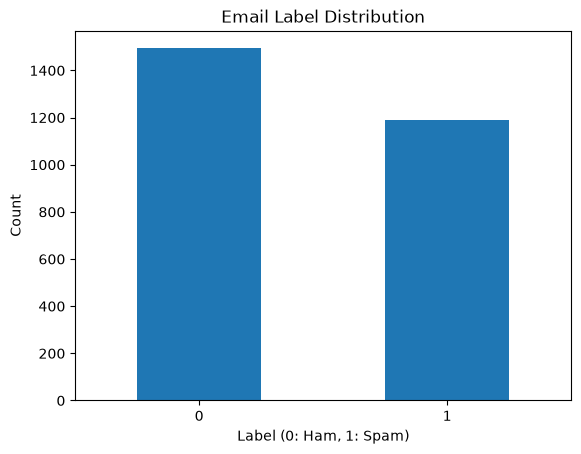

In [31]:
# 7. EDA(4) : 정상·스팸 클래스 분포 확인
# label 0: 비스팸 이메일
# label 1: 스팸 이메일

label_count = (
    email_data['label']
    .value_counts()
    .sort_index()
)

label_ratio = (
    email_data['label']
    .value_counts(normalize=True)
    .sort_index()
)

print('라벨별 개수')
print(label_count)

print('-' * 60)
print('라벨별 비율')
print(label_ratio)

label_count.plot(kind='bar')

plt.title('Email Label Distribution')
plt.xlabel('Label (0: Ham, 1: Spam)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


In [32]:
# 8. EDA(5) : 이메일 문자열 길이 분포 확인
#
# 숫자 데이터에서는 IQR을 이용해 이상치를 제거할 수 있지만,
# 이메일이 길다는 이유만으로 잘못된 데이터라고 볼 수 없다.
# 긴 이메일 자체가 정상 또는 스팸의 특징일 수 있으므로 제거하지 않고 분포만 확인한다.

email_data['text_length'] = (
    email_data['text']
    .astype(str)
    .str.len()
)

print('전체 문자열 길이 통계')
print(email_data['text_length'].describe())

print('-' * 60)
print('라벨별 문자열 길이 통계')
print(
    email_data
    .groupby('label')['text_length']
    .describe()
)


전체 문자열 길이 통계
count    2681.000000
mean      100.614323
std        42.203669
min         1.000000
25%        84.000000
50%        87.000000
75%       125.000000
max       367.000000
Name: text_length, dtype: float64
------------------------------------------------------------
라벨별 문자열 길이 통계
        count        mean        std  min   25%    50%    75%    max
label                                                               
0      1493.0   85.854655  30.324159  1.0  84.0   85.0   86.0  323.0
1      1188.0  119.163300  47.405387  5.0  91.0  129.0  142.0  367.0


In [33]:
# 9. 데이터 전처리
#
# 1) label 또는 text가 없는 행 제거
# 2) text를 문자열로 변환
# 3) 여러 공백과 줄바꿈을 공백 한 칸으로 정리
# 4) 빈 문자열 제거
# 5) label과 text가 완전히 같은 중복 행 제거

email_data = email_data.dropna(
    subset=['label', 'text']
).copy()

email_data['text'] = (
    email_data['text']
    .astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

email_data = email_data[
    email_data['text'] != ''
].copy()

email_data = (
    email_data
    .drop_duplicates(
        subset=['label', 'text']
    )
    .reset_index(drop=True)
)

print('전처리 후 데이터 크기:', email_data.shape)

print('-' * 60)
print('전처리 후 라벨 분포')
print(
    email_data['label']
    .value_counts()
    .sort_index()
)


전처리 후 데이터 크기: (2681, 3)
------------------------------------------------------------
전처리 후 라벨 분포
label
0    1493
1    1188
Name: count, dtype: int64


In [34]:
# 10. feature(X), target(y) 분리
#
# X: 모델에 입력할 이메일 문자열
# y: 모델이 맞혀야 하는 정답 라벨

X = email_data['text']
y = email_data['label'].astype(int)

print('X 크기:', X.shape)
print('y 크기:', y.shape)


X 크기: (2681,)
y 크기: (2681,)


In [35]:
# 11. 학습 데이터와 테스트 데이터 8:2 분리
#
# random_state=42:
# 실행할 때마다 같은 방식으로 분리하기 위한 값
#
# stratify=y:
# 학습 데이터와 테스트 데이터의 정상·스팸 비율을 비슷하게 유지

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('학습 데이터 크기:', X_train.shape)
print('테스트 데이터 크기:', X_test.shape)

print('-' * 60)
print('학습 데이터 라벨 분포')
print(y_train.value_counts().sort_index())

print('-' * 60)
print('테스트 데이터 라벨 분포')
print(y_test.value_counts().sort_index())


학습 데이터 크기: (2144,)
테스트 데이터 크기: (537,)
------------------------------------------------------------
학습 데이터 라벨 분포
label
0    1194
1     950
Name: count, dtype: int64
------------------------------------------------------------
테스트 데이터 라벨 분포
label
0    299
1    238
Name: count, dtype: int64


## TF-IDF와 LinearSVC

- 이메일의 `text`는 문자열이므로 LinearSVC 모델에 직접 입력할 수 없다.
- `TfidfVectorizer`가 이메일 문자열을 단어 중요도 기반 숫자 벡터로 변환한다.
- LinearSVC는 정상과 스팸 데이터 사이의 여유 거리인 Margin을 크게 만드는 선형 결정 경계를 찾는다.
- TF-IDF처럼 특성 수가 많고 대부분의 값이 0인 고차원 희소 텍스트 데이터에 적합하다.
- `Pipeline`을 사용하면 TF-IDF 변환과 LinearSVC를 하나의 모델처럼 관리할 수 있다.
- TF-IDF 결과에는 자체 정규화가 적용되므로 `StandardScaler` 표준화는 별도로 적용하지 않는다.
- 분류 문제이므로 R²가 아니라 Accuracy, Precision, Recall, F1-score와 혼동행렬로 평가한다.
- LinearSVC는 기본적으로 `predict_proba()`를 지원하지 않으므로 확률 대신 `decision_function()`의 결정 점수를 확인한다.


In [36]:
# 12. TF-IDF + LinearSVC Pipeline 정의

linearsvc_model = Pipeline([
    (
        'tfidf',
        TfidfVectorizer(
            ngram_range=(1, 2),  # 한 단어와 연속된 두 단어 사용
            min_df=2,            # 2개 미만 문서에 등장한 단어 제외
            max_features=20000,  # 최대 특성 개수
            sublinear_tf=True    # 반복 단어 횟수의 과도한 영향 완화
        )
    ),
    (
        'model',
        LinearSVC(
            C=1.0,
            random_state=42
        )
    )
])

linearsvc_model


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('model', LinearSVC(random_state=42))])

In [37]:
# 13. LinearSVC 모델 학습

linearsvc_model.fit(
    X_train,
    y_train
)

print('모델 학습 완료')


모델 학습 완료


In [38]:
# 14. 테스트 데이터 예측

y_pred = linearsvc_model.predict(
    X_test
)

print('예측 완료')
print('예측 결과 개수:', len(y_pred))


예측 완료
예측 결과 개수: 537


In [39]:
# 15. LinearSVC 모델 성능 평가

print(
    'Accuracy :',
    accuracy_score(y_test, y_pred)
)

print(
    'Precision:',
    precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print(
    'Recall   :',
    recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print(
    'F1-score :',
    f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print('-' * 60)
print('Confusion Matrix')

print(
    confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )
)

print('-' * 60)
print('Classification Report')

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=['비스팸', '스팸'],
        digits=4,
        zero_division=0
    )
)


Accuracy : 0.9869646182495344
Precision: 0.9714285714285714
Recall   : 1.0
F1-score : 0.9855072463768116
------------------------------------------------------------
Confusion Matrix
[[292   7]
 [  0 238]]
------------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

         비스팸     1.0000    0.9766    0.9882       299
          스팸     0.9714    1.0000    0.9855       238

    accuracy                         0.9870       537
   macro avg     0.9857    0.9883    0.9868       537
weighted avg     0.9873    0.9870    0.9870       537



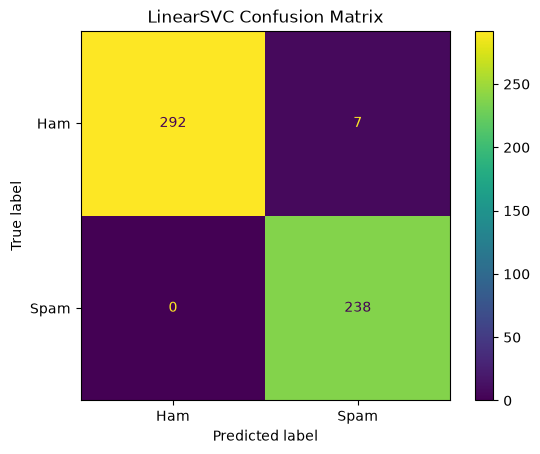

In [40]:
# 16. 혼동행렬 시각화

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=[0, 1],
    display_labels=['Ham', 'Spam'],
    values_format='d'
)

plt.title(
    'LinearSVC Confusion Matrix'
)

plt.show()


In [41]:
# 17. 새로운 이메일 예측 및 결정 점수 확인
#
# LinearSVC는 predict_proba()를 기본 제공하지 않는다.
# decision_function()의 결정 점수를 사용한다.
#
# 점수 > 0  : 스팸 방향
# 점수 < 0  : 비스팸 방향
# 절댓값이 클수록 해당 방향으로 더 멀리 떨어져 있다는 뜻이다.
# 이 점수는 확률이 아니다.

sample_emails = [
    '제목: 회의 일정 안내 본문: 내일 오후 2시에 회의를 진행합니다. 자료를 확인해 주세요.',
    '제목: 긴급 계정 정지 예정 본문: 지금 링크에서 비밀번호와 인증번호를 입력하지 않으면 계정이 정지됩니다.'
]

sample_predictions = (
    linearsvc_model.predict(
        sample_emails
    )
)

sample_scores = (
    linearsvc_model.decision_function(
        sample_emails
    )
)

for text, prediction, score in zip(
    sample_emails,
    sample_predictions,
    sample_scores
):
    print('-' * 60)
    print('입력:', text)

    print(
        '예측:',
        '스팸' if prediction == 1 else '비스팸'
    )

    print(
        '스팸 결정 점수:',
        round(float(score), 4)
    )


------------------------------------------------------------
입력: 제목: 회의 일정 안내 본문: 내일 오후 2시에 회의를 진행합니다. 자료를 확인해 주세요.
예측: 비스팸
스팸 결정 점수: -0.3509
------------------------------------------------------------
입력: 제목: 긴급 계정 정지 예정 본문: 지금 링크에서 비밀번호와 인증번호를 입력하지 않으면 계정이 정지됩니다.
예측: 스팸
스팸 결정 점수: 0.9196


## 최종 모델 저장 방식

앞에서 평가한 `linearsvc_model`은 학습 데이터 80%로만 학습된 평가용 모델이다.

실제 Streamlit에서 사용할 최종 모델은 모델 구조와 설정을 확정한 뒤, 전처리가 끝난 이메일 전체 데이터를 다시 학습하여 저장한다.

`.pkl` 파일에는 다음 두 단계가 함께 저장된다.

```text
문자열 이메일
→ TF-IDF 숫자 벡터 변환
→ LinearSVC 예측
```

따라서 Streamlit에서는 TF-IDF를 별도로 구현하지 않고, 불러온 모델에 문자열 리스트를 바로 전달할 수 있다.

LinearSVC는 기본적으로 스팸 확률을 제공하지 않으므로 다음 결과를 사용할 수 있다.

```text
predict()
→ 최종 라벨 0 또는 1

decision_function()
→ 결정 경계에서 떨어진 방향과 거리
```


In [42]:
# 18. 전체 이메일 데이터로 최종 모델 재학습

final_linearsvc_model = Pipeline([
    (
        'tfidf',
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=20000,
            sublinear_tf=True
        )
    ),
    (
        'model',
        LinearSVC(
            C=1.0,
            random_state=42
        )
    )
])

final_linearsvc_model.fit(
    X,
    y
)

print('전체 이메일 데이터 재학습 완료')


전체 이메일 데이터 재학습 완료


In [43]:
# 19. 최종 Pipeline을 pkl 파일로 저장

MODEL_PATH = 'email_spam_linearsvc_tfidf_v3.pkl'

with open(
    MODEL_PATH,
    'wb'
) as file:
    pickle.dump(
        final_linearsvc_model,
        file
    )

print(
    '모델 저장 완료:',
    MODEL_PATH
)


모델 저장 완료: email_spam_linearsvc_tfidf_v3.pkl


In [44]:
# 20. 저장된 pkl 모델 불러오기

with open(
    'email_spam_linearsvc_tfidf_v3.pkl',
    'rb'
) as file:
    loaded_model = pickle.load(file)

print('pkl 모델 불러오기 완료')


pkl 모델 불러오기 완료


In [45]:
# 21. 불러온 모델로 예측 확인

# new_email = [
#     '제목: 배송 주소 오류 안내 본문: 재배송을 위해 링크에서 카드번호를 입력해 주세요.'
# ]

new_email = [
     '안녕하세요 반갑습니다.'
 ]


prediction = loaded_model.predict(
    new_email
)[0]

decision_score = loaded_model.decision_function(
    new_email
)[0]

print(
    '예측 결과:',
    '스팸' if prediction == 1 else '비스팸'
)

print(
    '스팸 결정 점수:',
    round(float(decision_score), 4)
)


예측 결과: 비스팸
스팸 결정 점수: -0.5787


## 실행 후 생성되는 파일

```text
email_spam_linearsvc_tfidf.pkl
```

Streamlit에서는 다음처럼 사용할 수 있다.

```python
import pickle

with open(
    'email_spam_linearsvc_tfidf.pkl',
    'rb'
) as file:
    model = pickle.load(file)

input_text = '사용자가 입력한 이메일'

prediction = model.predict(
    [input_text]
)[0]

decision_score = model.decision_function(
    [input_text]
)[0]

print(
    '스팸' if prediction == 1 else '비스팸'
)

print('결정 점수:', decision_score)
```

## LinearSVC 결정 점수 해석

```text
결정 점수 > 0
→ 스팸 방향

결정 점수 < 0
→ 비스팸 방향

결정 점수의 절댓값이 큼
→ 결정 경계에서 더 멀리 떨어져 있음
```

결정 점수는 0~1 사이의 확률이 아니다.

## 해석 시 주의사항

- 현재 데이터의 정상·스팸 비율은 심하게 불균형하지 않으므로 재샘플링과 `class_weight='balanced'`는 적용하지 않았다.
- 이메일 길이는 단순 숫자 이상치로 제거하지 않았다.
- 제목과 본문의 실제 내용은 모두 학습에 사용한다.
- LinearSVC는 TF-IDF와 같은 고차원 희소 텍스트 데이터에 적합한 선형 분류 모델이다.
- 내부 테스트 성능이 높더라도 실제 이메일에 대한 성능을 의미하지는 않으므로, 학습에 사용하지 않은 별도 외부 테스트 데이터로 추가 평가해야 한다.
